In [ ]:
!pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 42.2 MB/s eta 0:00:00


  0%|          | 0/1000000 [00:00<?, ?it/s]


Company: PG - P(Return_bin):
+---------------+-------------------+
| Return_bin    |   phi(Return_bin) |
+===============+===================+
| Return_bin(0) |            0.4602 |
+---------------+-------------------+
| Return_bin(1) |            0.5398 |
+---------------+-------------------+


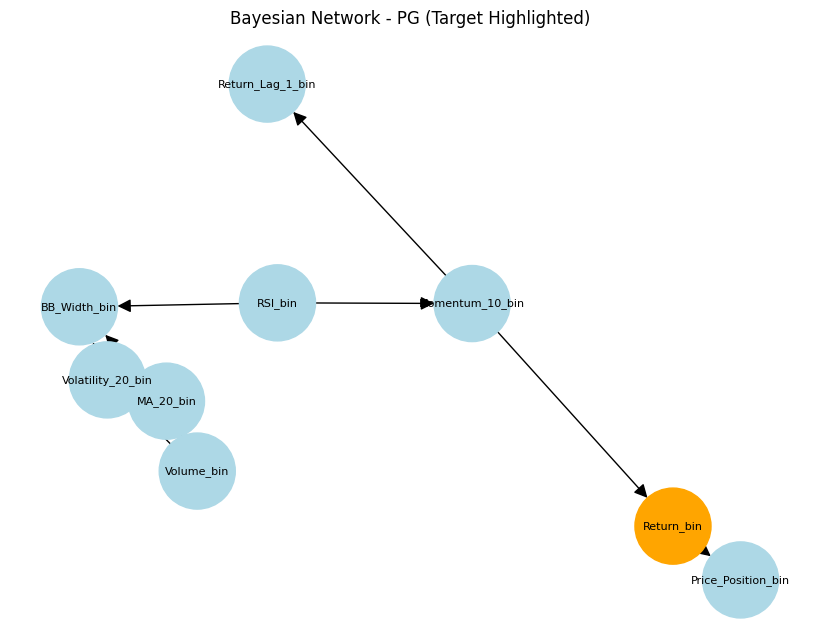

  0%|          | 0/1000000 [00:00<?, ?it/s]


Company: AAPL - P(Return_bin):
+---------------+-------------------+
| Return_bin    |   phi(Return_bin) |
+===============+===================+
| Return_bin(0) |            0.4656 |
+---------------+-------------------+
| Return_bin(1) |            0.5344 |
+---------------+-------------------+


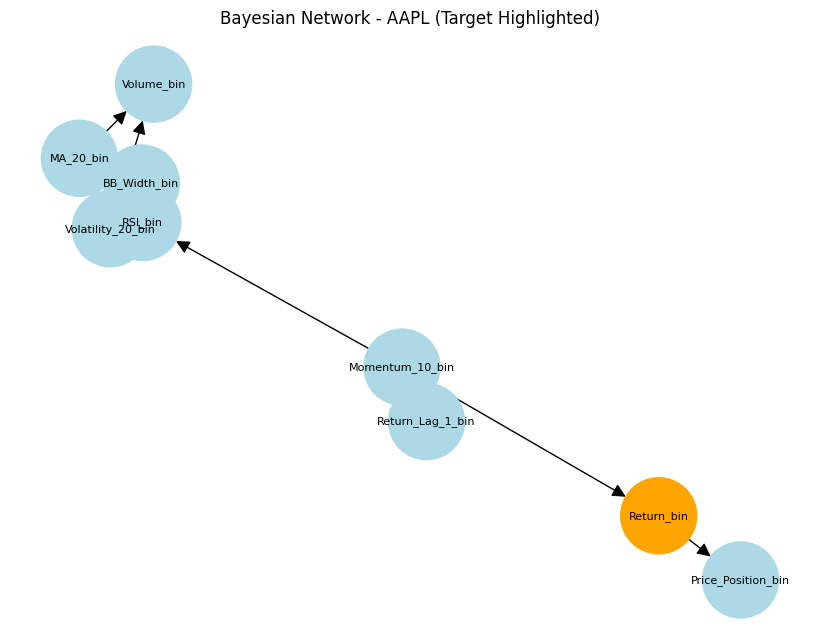

  0%|          | 0/1000000 [00:00<?, ?it/s]


Company: JNJ - P(Return_bin):
+---------------+-------------------+
| Return_bin    |   phi(Return_bin) |
+===============+===================+
| Return_bin(0) |            0.4805 |
+---------------+-------------------+
| Return_bin(1) |            0.5195 |
+---------------+-------------------+


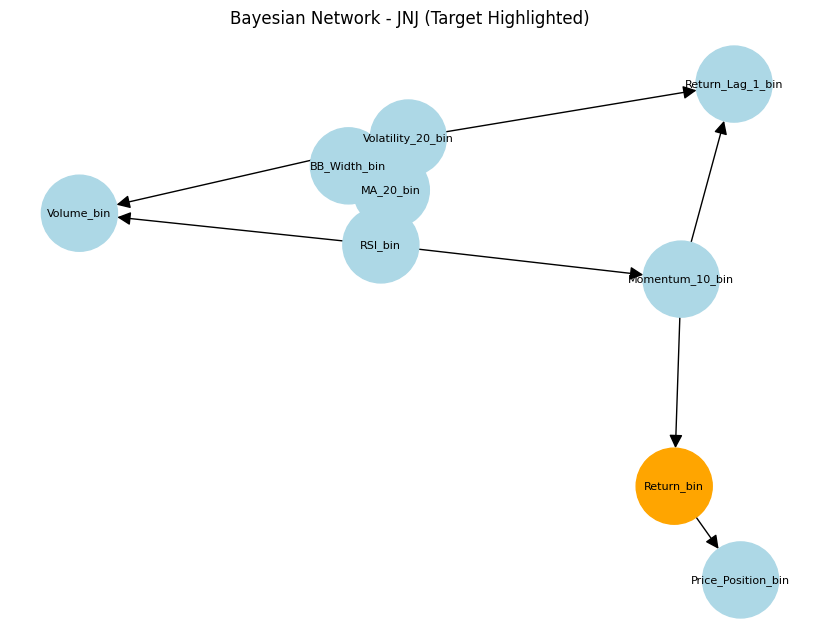

  0%|          | 0/1000000 [00:00<?, ?it/s]


Company: JPM - P(Return_bin):
+---------------+-------------------+
| Return_bin    |   phi(Return_bin) |
+===============+===================+
| Return_bin(0) |            0.4794 |
+---------------+-------------------+
| Return_bin(1) |            0.5206 |
+---------------+-------------------+


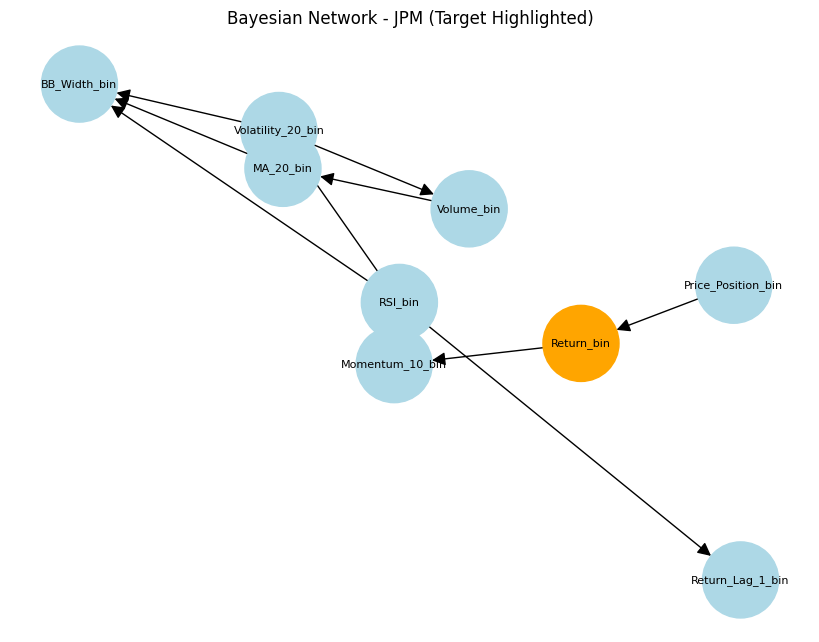

  0%|          | 0/1000000 [00:00<?, ?it/s]


Company: XOM - P(Return_bin):
+---------------+-------------------+
| Return_bin    |   phi(Return_bin) |
+===============+===================+
| Return_bin(0) |            0.4907 |
+---------------+-------------------+
| Return_bin(1) |            0.5093 |
+---------------+-------------------+


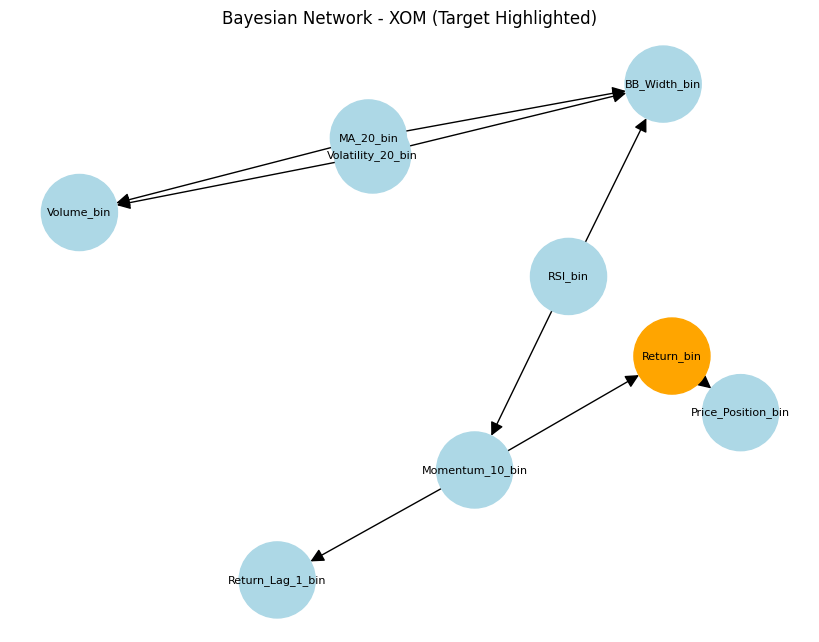

In [ ]:
import pandas as pd
import numpy as np
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import HillClimbSearch, BIC
from pgmpy.inference import VariableElimination
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------
# 1. Load CSVs with Company Column
# -----------------------
csv_files = {
    "PG_daily_data.csv": "PG",
    "AAPL_daily_data.csv": "AAPL",
    "JNJ_daily_data.csv": "JNJ",
    "JPM_daily_data.csv": "JPM",
    "XOM_daily_data.csv": "XOM"
}

data_list = []
for file, company in csv_files.items():
    df = pd.read_csv(file)
    df["Company"] = company
    data_list.append(df)

df_all = pd.concat(data_list, ignore_index=True)

# -----------------------
# 2. Define features and discretize
# -----------------------
def preprocess(df):
    df = df.dropna().copy()
    df["Return_bin"] = np.where(df["Return"] > 0, 1, 0)
    df["Volatility_20_bin"] = np.where(df["Volatility_20"] > df["Volatility_20"].median(), 1, 0)
    df["Momentum_10_bin"] = np.where(df["Momentum_10"] > df["Momentum_10"].median(), 1, 0)
    df["Volume_bin"] = np.where(df["Volume"] > df["Volume"].median(), 1, 0)
    df["RSI_bin"] = pd.cut(df["RSI"], bins=[0, 30, 70, 100], labels=[0, 1, 2])
    df["Price_Position_bin"] = pd.qcut(df["Price_Position"], q=3, labels=[0, 1, 2])
    df["MA_20_bin"] = np.where(df["MA_20"] > df["MA_20"].median(), 1, 0)
    df["BB_Width_bin"] = pd.qcut(df["BB_Width"], q=3, labels=[0, 1, 2])
    df["Return_Lag_1_bin"] = np.where(df["Return_Lag_1"] > 0, 1, 0)

    cols = [
        "Return_bin", "Volatility_20_bin", "Momentum_10_bin", "Volume_bin",
        "RSI_bin", "Price_Position_bin", "MA_20_bin", "BB_Width_bin", "Return_Lag_1_bin"
    ]
    return df[cols].dropna()

# -----------------------
# 3. Learn BN & Plot per Company (with target node highlighted)
# -----------------------
companies = ["PG", "AAPL", "JNJ", "JPM", "XOM"]

for comp in companies:
    comp_data = df_all[df_all["Company"] == comp]
    disc_data = preprocess(comp_data)


    hc = HillClimbSearch(disc_data)
    best_model = hc.estimate(scoring_method=BIC(disc_data))

    # Build BN
    edges = list(best_model.edges())
    target = "Return_bin"
    for var in disc_data.columns:
        if var != target and not any(var in e for e in edges):
            edges.append((var, target))

    model = DiscreteBayesianNetwork(edges)
    model.fit(disc_data)


    infer = VariableElimination(model)
    print(f"\nCompany: {comp} - P(Return_bin):")
    print(infer.query(variables=[target], evidence={}))

    # Plot BN with target node highlighted
    plt.figure(figsize=(8,6))
    G = nx.DiGraph()
    G.add_nodes_from(model.nodes())
    G.add_edges_from(model.edges())

    pos = nx.spring_layout(G, seed=42)

    # Color nodes: target in orange, others in lightblue
    node_colors = ["orange" if node == target else "lightblue" for node in G.nodes()]

    nx.draw(
        G, pos, with_labels=True, node_size=3000,
        node_color=node_colors, font_size=8, arrowsize=20
    )
    plt.title(f"Bayesian Network - {comp} (Target Highlighted)")
    plt.show()


/tmp/ipython-input-708360867.py:25: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["Date"] = pd.to_datetime(df["Date"])  # ensure datetime
/tmp/ipython-input-708360867.py:25: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["Date"] = pd.to_datetime(df["Date"])  # ensure datetime
/tmp/ipython-input-708360867.py:25: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Pleas

  0%|          | 0/1000000 [00:00<?, ?it/s]


Company: PG - Confusion Matrix
[[61 19]
 [24 70]]

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.76      0.74        80
           1       0.79      0.74      0.77        94

    accuracy                           0.75       174
   macro avg       0.75      0.75      0.75       174
weighted avg       0.75      0.75      0.75       174



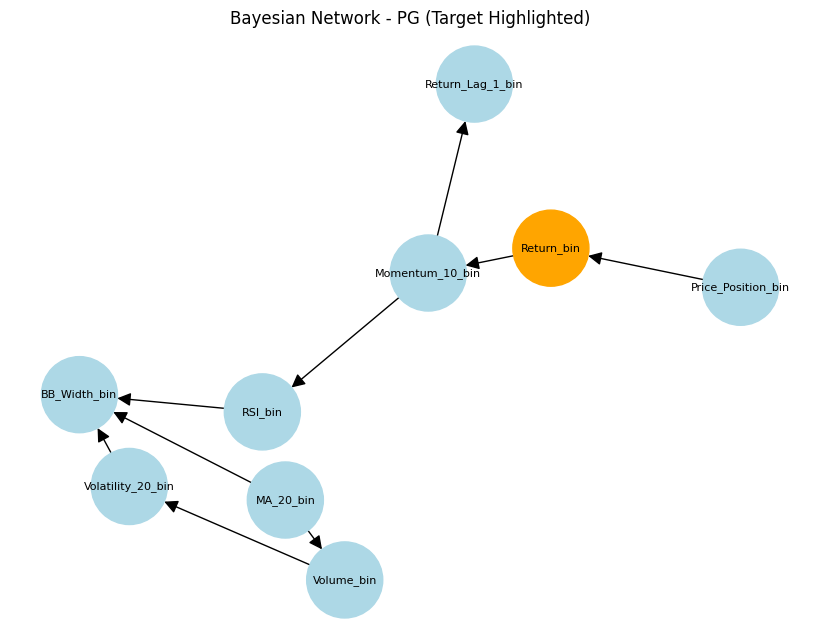

  0%|          | 0/1000000 [00:00<?, ?it/s]


Company: AAPL - Confusion Matrix
[[52 34]
 [11 77]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.60      0.70        86
           1       0.69      0.88      0.77        88

    accuracy                           0.74       174
   macro avg       0.76      0.74      0.74       174
weighted avg       0.76      0.74      0.74       174



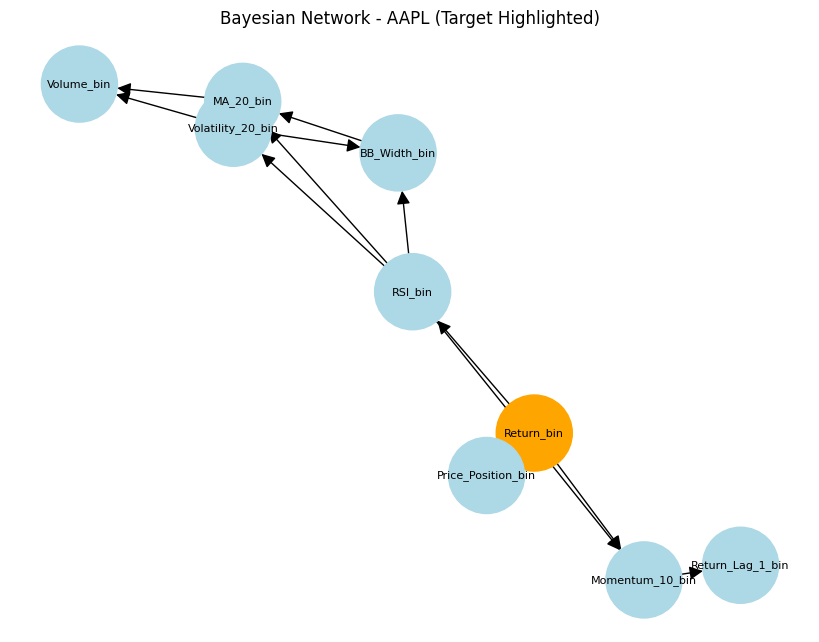

  0%|          | 0/1000000 [00:00<?, ?it/s]


Company: JNJ - Confusion Matrix
[[61 13]
 [29 71]]

Classification Report
              precision    recall  f1-score   support

           0       0.68      0.82      0.74        74
           1       0.85      0.71      0.77       100

    accuracy                           0.76       174
   macro avg       0.76      0.77      0.76       174
weighted avg       0.77      0.76      0.76       174



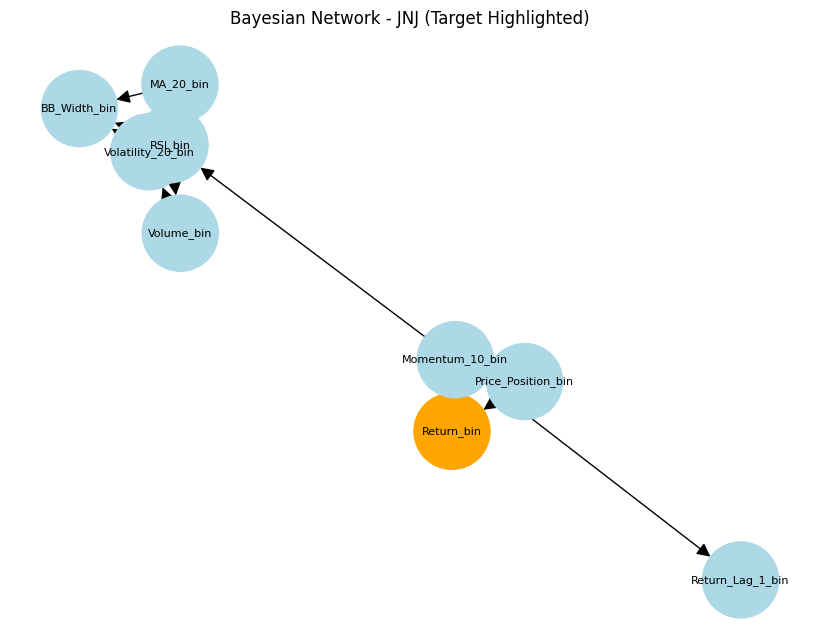

  0%|          | 0/1000000 [00:00<?, ?it/s]


Company: JPM - Confusion Matrix
[[63 11]
 [32 68]]

Classification Report
              precision    recall  f1-score   support

           0       0.66      0.85      0.75        74
           1       0.86      0.68      0.76       100

    accuracy                           0.75       174
   macro avg       0.76      0.77      0.75       174
weighted avg       0.78      0.75      0.75       174



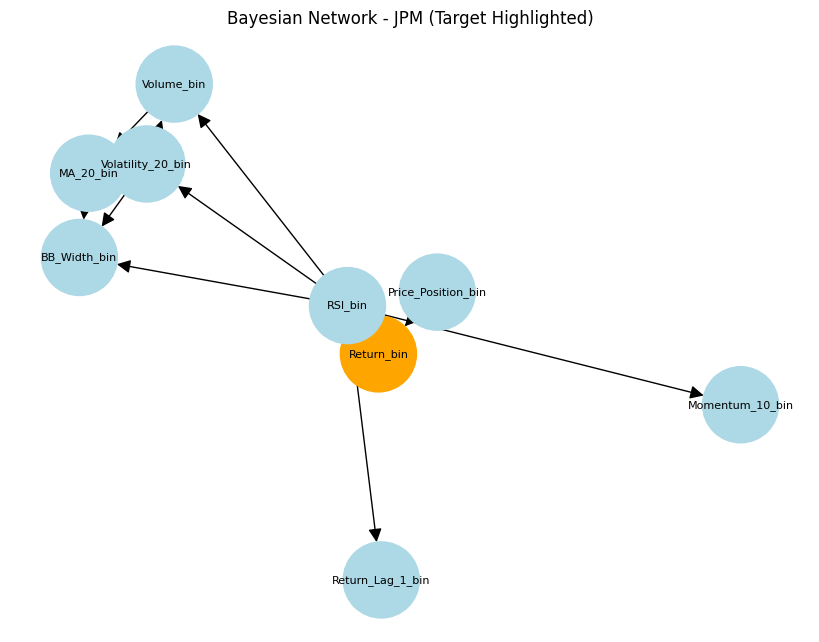

  0%|          | 0/1000000 [00:00<?, ?it/s]


Company: XOM - Confusion Matrix
[[58 18]
 [29 69]]

Classification Report
              precision    recall  f1-score   support

           0       0.67      0.76      0.71        76
           1       0.79      0.70      0.75        98

    accuracy                           0.73       174
   macro avg       0.73      0.73      0.73       174
weighted avg       0.74      0.73      0.73       174



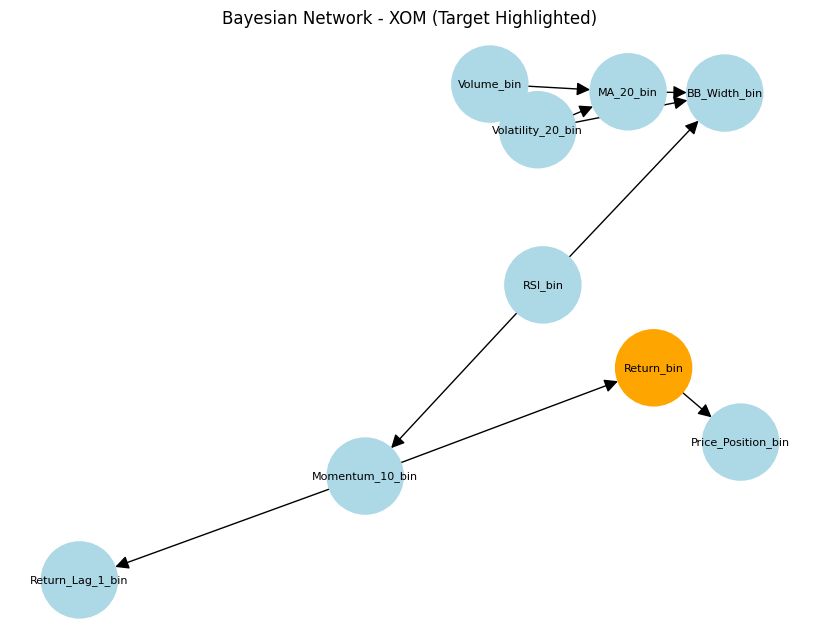

In [ ]:
import pandas as pd
import numpy as np
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import HillClimbSearch, BIC
from pgmpy.inference import VariableElimination
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# -----------------------
# 1. Load CSVs with Company Column
# -----------------------
csv_files = {
    "PG_daily_data_new.csv": "PG",
    "AAPL_daily_data_new.csv": "AAPL",
    "JNJ_daily_data_new.csv": "JNJ",
    "JPM_daily_data_new.csv": "JPM",
    "XOM_daily_data_new.csv": "XOM"
}

data_list = []
for file, company in csv_files.items():
    df = pd.read_csv(file)
    df["Company"] = company
    df["Date"] = pd.to_datetime(df["Date"])  # ensure datetime
    data_list.append(df)

df_all = pd.concat(data_list, ignore_index=True)

# -----------------------
# 2. Define features and discretize
# -----------------------
def preprocess(df):
    df = df.dropna().copy()
    df["Return_bin"] = np.where(df["Return"] > 0, 1, 0)
    df["Volatility_20_bin"] = np.where(df["Volatility_20"] > df["Volatility_20"].median(), 1, 0)
    df["Momentum_10_bin"] = np.where(df["Momentum_10"] > df["Momentum_10"].median(), 1, 0)
    df["Volume_bin"] = np.where(df["Volume"] > df["Volume"].median(), 1, 0)
    df["RSI_bin"] = pd.cut(df["RSI"], bins=[0, 30, 70, 100], labels=[0, 1, 2])
    df["Price_Position_bin"] = pd.qcut(df["Price_Position"], q=3, labels=[0, 1, 2])
    df["MA_20_bin"] = np.where(df["MA_20"] > df["MA_20"].median(), 1, 0)
    df["BB_Width_bin"] = pd.qcut(df["BB_Width"], q=3, labels=[0, 1, 2])
    df["Return_Lag_1_bin"] = np.where(df["Return_Lag_1"] > 0, 1, 0)

    cols = [
        "Return_bin", "Volatility_20_bin", "Momentum_10_bin", "Volume_bin",
        "RSI_bin", "Price_Position_bin", "MA_20_bin", "BB_Width_bin", "Return_Lag_1_bin"
    ]
    return df[cols].dropna()

# -----------------------
# 3. Train/Test split & BN per company
# -----------------------
cutoff_date = pd.to_datetime("2025-01-01")


cutoff_date = cutoff_date.tz_localize(df_all["Date"].iloc[0].tzinfo)


companies = ["PG", "AAPL", "JNJ", "JPM", "XOM"]

for comp in companies:
    comp_data = df_all[df_all["Company"] == comp]

    train_data = comp_data[comp_data["Date"] < cutoff_date]
    test_data  = comp_data[comp_data["Date"] >= cutoff_date]

    disc_train = preprocess(train_data)
    disc_test  = preprocess(test_data)


    hc = HillClimbSearch(disc_train)
    best_model = hc.estimate(scoring_method=BIC(disc_train))

    # Build BN
    edges = list(best_model.edges())
    target = "Return_bin"
    for var in disc_train.columns:
        if var != target and not any(var in e for e in edges):
            edges.append((var, target))

    model = DiscreteBayesianNetwork(edges)
    model.fit(disc_train)

    # -----------------------
    # Inference on test set
    # -----------------------
    infer = VariableElimination(model)
    y_true = disc_test[target].values
    y_pred = []

    for _, row in disc_test.iterrows():
        evidence = row.drop(target).to_dict()
        q = infer.query(variables=[target], evidence=evidence)
        pred = 1 if q.values[1] > 0.5 else 0
        y_pred.append(pred)

    # Confusion matrix & classification report
    print(f"\nCompany: {comp} - Confusion Matrix")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print("\nClassification Report")
    print(classification_report(y_true, y_pred))

    # -----------------------
    # Plot BN with target highlighted
    # -----------------------
    plt.figure(figsize=(8,6))
    G = nx.DiGraph()
    G.add_nodes_from(model.nodes())
    G.add_edges_from(model.edges())
    pos = nx.spring_layout(G, seed=42)
    node_colors = ["orange" if node == target else "lightblue" for node in G.nodes()]
    nx.draw(G, pos, with_labels=True, node_size=3000, node_color=node_colors,
            font_size=8, arrowsize=20)
    plt.title(f"Bayesian Network - {comp} (Target Highlighted)")
    plt.show()

  0%|          | 0/1000000 [00:00<?, ?it/s]

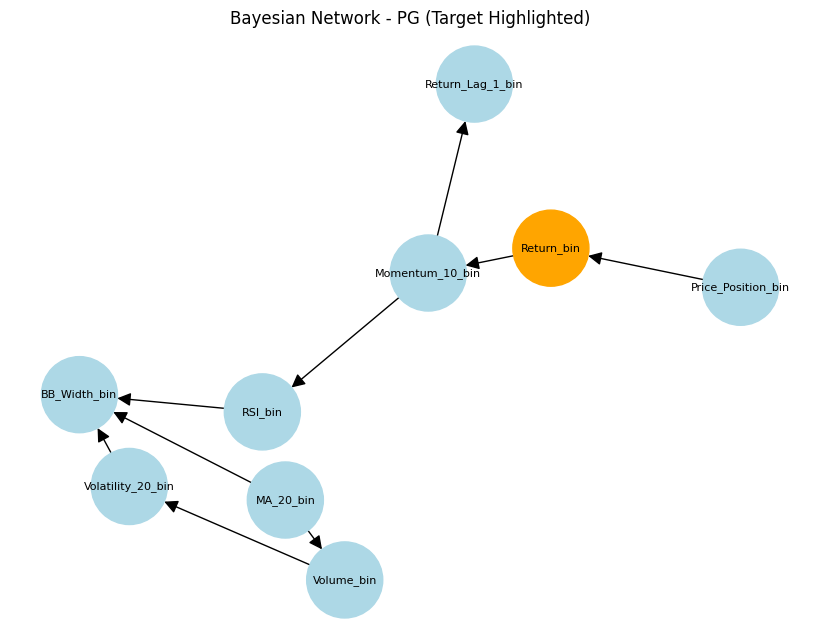

  0%|          | 0/1000000 [00:00<?, ?it/s]

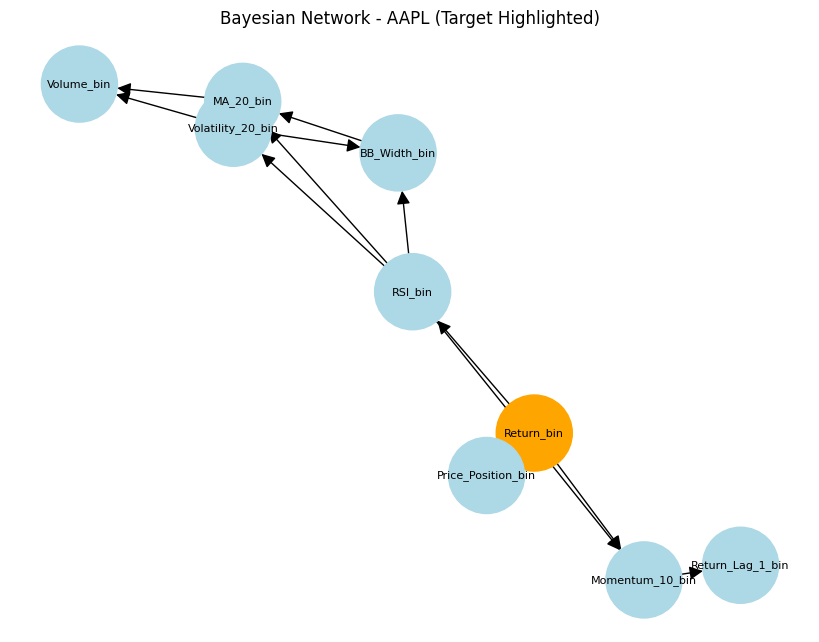

  0%|          | 0/1000000 [00:00<?, ?it/s]

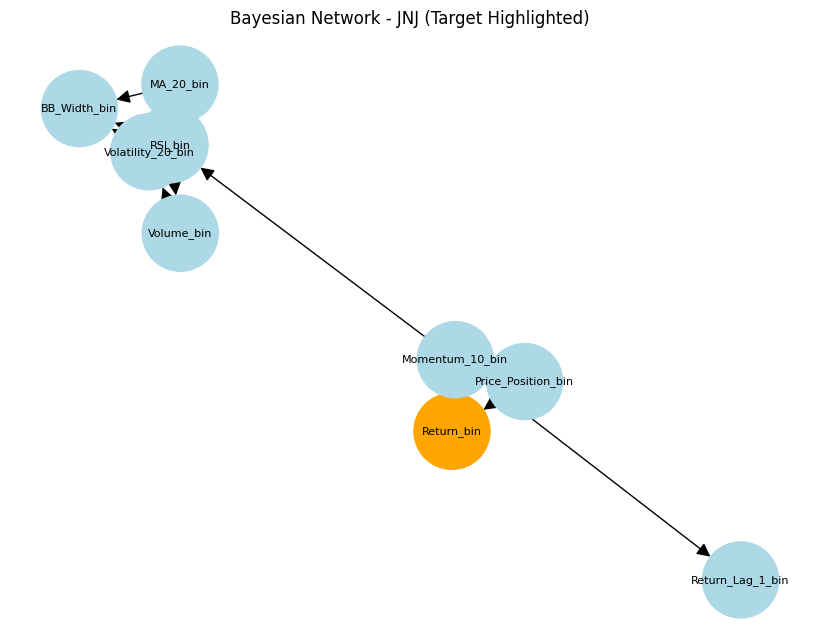

  0%|          | 0/1000000 [00:00<?, ?it/s]

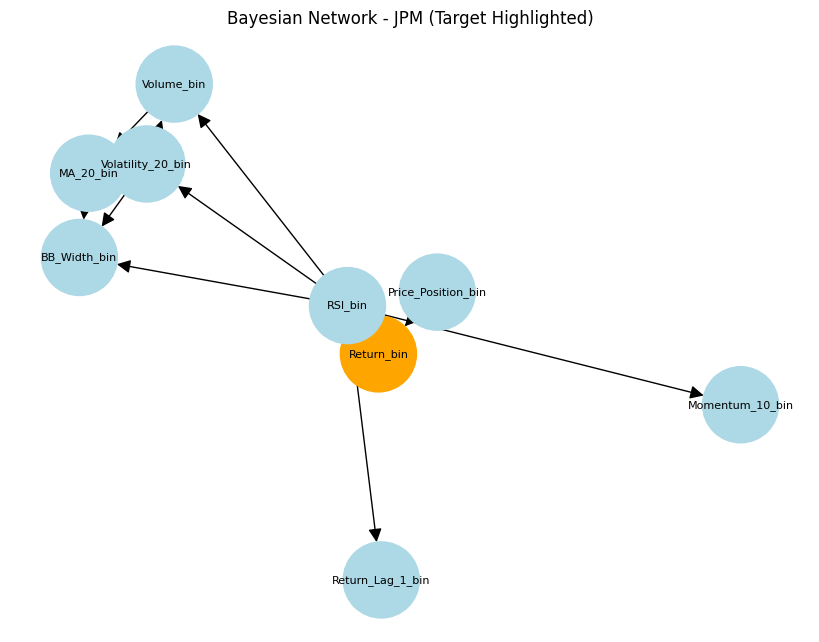

  0%|          | 0/1000000 [00:00<?, ?it/s]

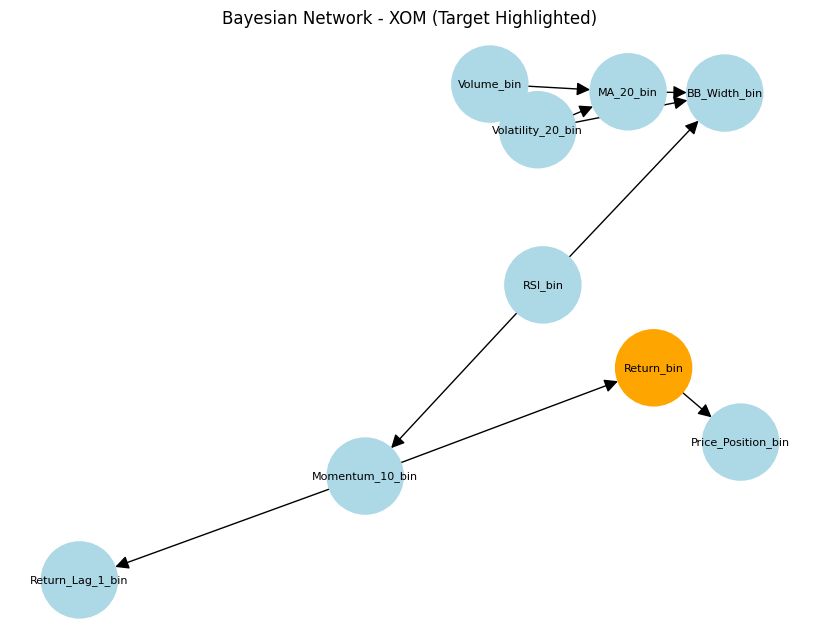


Summary of BN Predictive Performance for All Companies:
  Company  Accuracy  Precision  Recall  F1-Score
0      PG     0.753      0.787   0.745     0.765
1    AAPL     0.741      0.694   0.875     0.774
2     JNJ     0.759      0.845   0.710     0.772
3     JPM     0.753      0.861   0.680     0.760
4     XOM     0.730      0.793   0.704     0.746

Predicted Return_bin probabilities for April 7-11, 2025:


TypeError: Cannot compare tz-naive and tz-aware timestamps

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -----------------------
# Summary metrics dictionary
# -----------------------
summary_metrics = []

cutoff_date = pd.to_datetime("2025-01-01")


cutoff_date = cutoff_date.tz_localize(df_all["Date"].iloc[0].tzinfo)


companies = ["PG", "AAPL", "JNJ", "JPM", "XOM"]

for comp in companies:
    comp_data = df_all[df_all["Company"] == comp]

    train_data = comp_data[comp_data["Date"] < cutoff_date]
    test_data  = comp_data[comp_data["Date"] >= cutoff_date]

    disc_train = preprocess(train_data)
    disc_test  = preprocess(test_data)


    hc = HillClimbSearch(disc_train)
    best_model = hc.estimate(scoring_method=BIC(disc_train))

    # Build BN
    edges = list(best_model.edges())
    target = "Return_bin"
    for var in disc_train.columns:
        if var != target and not any(var in e for e in edges):
            edges.append((var, target))

    model = DiscreteBayesianNetwork(edges)
    model.fit(disc_train)

    # Predict on test set
    infer = VariableElimination(model)
    y_true = disc_test[target].values
    y_pred = []

    for _, row in disc_test.iterrows():
        evidence = row.drop(target).to_dict()
        q = infer.query(variables=[target], evidence=evidence)
        pred = 1 if q.values[1] > 0.5 else 0
        y_pred.append(pred)

    # Calculate metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    summary_metrics.append({
        "Company": comp,
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1-Score": round(f1, 3)
    })

    # Plot BN with target highlighted
    plt.figure(figsize=(8,6))
    G = nx.DiGraph()
    G.add_nodes_from(model.nodes())
    G.add_edges_from(model.edges())
    pos = nx.spring_layout(G, seed=42)
    node_colors = ["orange" if node == target else "lightblue" for node in G.nodes()]
    nx.draw(G, pos, with_labels=True, node_size=3000, node_color=node_colors,
            font_size=8, arrowsize=20)
    plt.title(f"Bayesian Network - {comp} (Target Highlighted)")
    plt.show()

# -----------------------
# Display summary table
# -----------------------
summary_df = pd.DataFrame(summary_metrics)
print("\nSummary of BN Predictive Performance for All Companies:")
print(summary_df)


